# **EDA - meteorología del Atlántico**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import geopandas as gpd
from scipy import stats
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.geometry import Point
from shapely.geometry import Polygon
import geopandas as gpd

In [9]:
df = pd.read_csv("Mapas/clima_atlantico.csv", encoding='utf-8', low_memory=False)
df['FECHA'] = pd.to_datetime(df['FECHA'], dayfirst=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14417 entries, 0 to 14416
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   CODIGO                      14417 non-null  int64         
 1   NOMBRE                      14417 non-null  object        
 2   FECHA                       14417 non-null  datetime64[ns]
 3   LATITUD                     14417 non-null  float64       
 4   LONGITUD                    14417 non-null  float64       
 5   ALTITUD                     14417 non-null  int64         
 6   HUM RELATIVA_MAX            2418 non-null   float64       
 7   HUM RELATIVA_MIN            2418 non-null   float64       
 8   PRECIPITACION_Convencional  12411 non-null  float64       
 9   TEMPERATURA_MAX             3677 non-null   float64       
 10  TEMPERATURA_MIN             4520 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(2), object(1)


## Estaciones

In [10]:
df['NOMBRE'].unique()

array(['NORMAL MANATI', 'AEROPUERTO E. CORTISSOZ', 'BARRANQUILLA SEDE',
       'JUAN DE ACOSTA', 'MONTEBELLO', 'CANDELARIA', 'LEÑA',
       'LOMA GRANDE', 'CASA DE BOMBAS', 'CAMPO DE LA CRUZ', 'HIBACHARO',
       'PIOJO', 'CAMPANOS LOS', 'PINTADA LA', 'POLONUEVO'], dtype=object)

In [11]:
print("Fechas")
print(f"Fecha mínima {df['FECHA'].min()}")
print(f'Fecha máxima {df['FECHA'].max()}')

Fechas
Fecha mínima 2016-12-31 00:00:00
Fecha máxima 2024-01-01 00:00:00


In [12]:
gdf = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding='utf_8')
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'}) 
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

C:\Users\Hp\AppData\Local\Temp\ipykernel_26564\2828522165.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_puntos['zona'] = gdf_puntos.geometry.buffer(0.05)  # Radio en grados (aprox. 1 km)


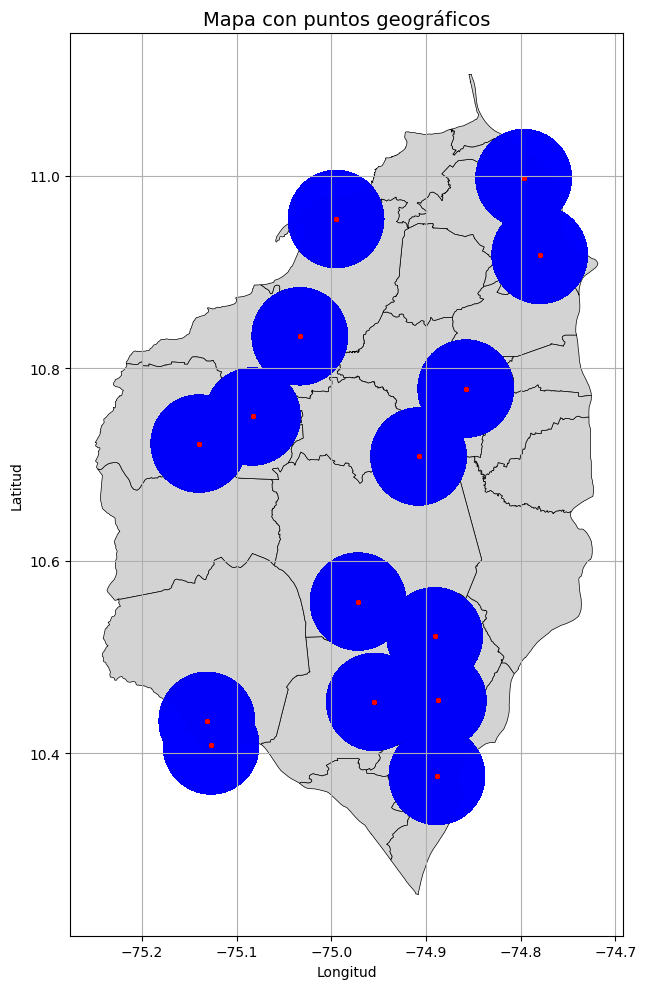

In [16]:
# 1. Convertir df a GeoDataFrame usando Latitud y Longitud
df['geometry'] = [Point(xy) for xy in zip(df['LONGITUD'], df['LATITUD'])]
gdf_puntos = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')  # CRS geográfico estándar
gdf_puntos['zona'] = gdf_puntos.geometry.buffer(0.05)  # Radio en grados (aprox. 1 km)

# 2. Asegurar que el shapefile también esté en EPSG:4326
gdf = gdf.to_crs('EPSG:4326')

# 3. Graficar mapa base y puntos
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)
gdf_puntos['zona'].plot(ax=ax, color='blue', alpha=0.2, edgecolor='blue')  # Círculos
gdf_puntos.plot(ax=ax, color='red', markersize=5, alpha=0.6)

# 4. Título y etiquetas en español
ax.set_title('Mapa con puntos geográficos', fontsize=14)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.grid(True)
plt.tight_layout()
plt.show()

## Clima

In [18]:
df.columns

Index(['CODIGO', 'NOMBRE', 'FECHA', 'LATITUD', 'LONGITUD', 'ALTITUD',
       'HUM RELATIVA_MAX', 'HUM RELATIVA_MIN', 'PRECIPITACION_Convencional',
       'TEMPERATURA_MAX', 'TEMPERATURA_MIN', 'geometry'],
      dtype='object')

In [19]:
df['HUM RELATIVA_MAX'].describe()

count    2418.000000
mean       96.211332
std         2.165190
min        87.000000
25%        95.000000
50%        97.000000
75%        98.000000
max       100.000000
Name: HUM RELATIVA_MAX, dtype: float64

<Axes: >

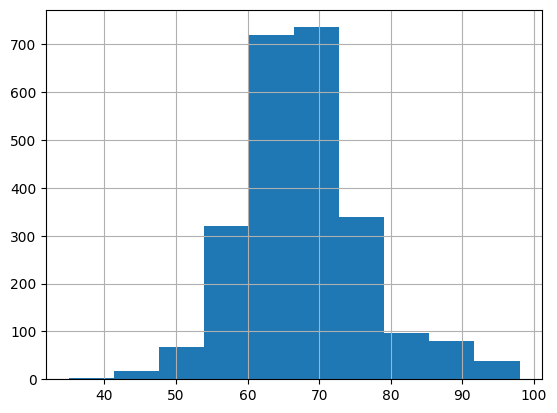

In [20]:
df['HUM RELATIVA_MIN'].hist()

In [21]:
df['PRECIPITACION_Convencional'].describe()

count    12411.000000
mean         9.240956
std         16.039534
min          0.000000
25%          0.000000
50%          1.600000
75%         12.000000
max        140.000000
Name: PRECIPITACION_Convencional, dtype: float64

<Axes: >

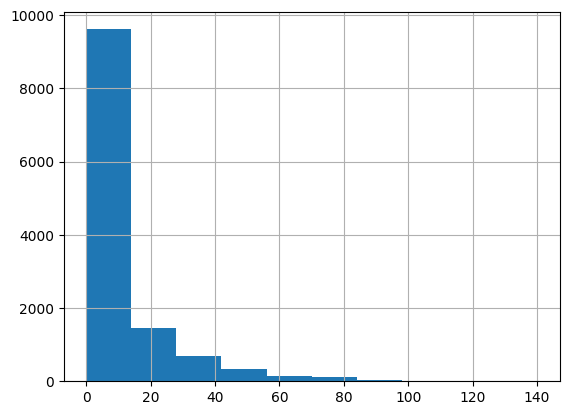

In [41]:
df['Precipitacion'].hist()

In [22]:
df['TEMPERATURA_MAX'].describe()

count    3677.000000
mean       33.738863
std         1.433534
min        26.400000
25%        33.000000
50%        34.000000
75%        34.600000
max        39.000000
Name: TEMPERATURA_MAX, dtype: float64

<Axes: >

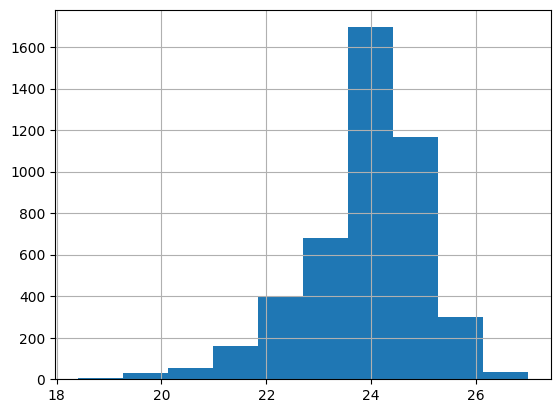

In [23]:
df['TEMPERATURA_MIN'].hist()